Understanding ERM Framework

Data pre - processing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_name'] = [iris.target_names[i] for i in iris.target]

print("Dataset Preview:")
print(df.head())
print("\nDataset Information:")
print(df.info())

Dataset Preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float6

Data Pre – processing

In [ ]:
# Step 3: Extract features (X) and target labels (y)
X = df.iloc[:, 1:-1].values   # All columns except the first (index) and last (target_name)
y = df.iloc[:, -1].values     # Last column (target)

# Step 4: Convert categorical labels to numeric
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)   # Convert labels to integers (0, 1, 2)

# Step 5: One-Hot Encode the labels
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_one_hot = one_hot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Display results
print("\nUnique Classes:", np.unique(y))
print("Encoded Labels:", np.unique(y_encoded))
print("One-Hot Encoded Labels:\n", y_one_hot[:5])   # Show first 5


Unique Classes: [np.str_('setosa') np.str_('versicolor') np.str_('virginica')]
Encoded Labels: [0 1 2]
One-Hot Encoded Labels:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


Train-Test Split

In [ ]:
# Step 6: Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_one_hot, test_size=0.2, random_state=42, stratify=y_one_hot
)

# Output shapes
print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape,  "y_test:", y_test.shape)


Shapes:
X_train: (120, 4) y_train: (120, 3)
X_test: (30, 4) y_test: (30, 3)


Softmax Function

In [ ]:
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.

    Parameters:
        z (numpy.ndarray): Logits (raw scores) of shape (m, n), where
                           - m is the number of samples
                           - n is the number of classes
    Returns:
        numpy.ndarray: Softmax probability matrix of shape (m, n),
                       each row sums to 1 and represents the probability
                       distribution over classes.

    Notes:
        - The input to softmax is typically computed as: z = XW + b
        - Uses numerical stabilization by subtracting the max value per row.
    """
    # Prevent numerical instability by normalizing input
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

Loss Function — Categorical Cross-Entropy

In [ ]:
def loss_softmax(y_pred, y):
    """
    Compute the cross-entropy loss.

    Parameters:
        y_pred (numpy.ndarray): Predicted probabilities of shape (n, c),
                                where n is the number of samples and
                                c is the number of classes.
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).

    Returns:
        float: Cross-entropy loss.
    """
    epsilon = 1e-12                                   # To avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon) # Prevent log(0) by clipping values
    n = y.shape[0]                                    # Number of samples
    loss = -np.sum(y * np.log(y_pred)) / n
    return loss

Cost Function

In [ ]:
def cost_softmax(X, y, W, b):
    """
    Compute the softmax regression cost (cross-entropy loss).

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        float: The softmax cost (cross-entropy loss).
    """
    n = X.shape[0]           # Number of samples
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    cost = loss_softmax(y_pred, y)
    return cost


Gradient Computation

In [ ]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function with respect to weights and biases.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        tuple: Gradients with respect to weights (d, c) and biases (c,).
    """
    n, d = X.shape
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    grad_W = np.dot(X.T, (y_pred - y)) / n   # Gradient with respect to weights
    grad_b = np.sum(y_pred - y, axis=0) / n  # Gradient with respect to biases
    return grad_W, grad_b

Gradient Descent

In [ ]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize the weights and biases.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).
        alpha (float): Learning rate.
        n_iter (int): Number of iterations.
        show_cost (bool): Whether to display the cost at intervals.

    Returns:
        tuple: Optimized weights, biases, and cost history.
    """
    cost_history = []
    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update weights and biases using the gradients
        W -= alpha * grad_W
        b -= alpha * grad_b

        # Compute and store cost
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        # Print cost at regular intervals
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return W, b, cost_history

Decision / Prediction Function

In [ ]:
def predict_softmax(X, W, b):
    """
    Predict the class labels for a set of samples using the trained softmax model.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        numpy.ndarray: Predicted class labels of shape (n,),
                       where each value is the index of the predicted class.
    """
    z = np.dot(X, W) + b          # Compute the scores (logits)
    y_pred = softmax(z)           # Get the probabilities using the softmax function

    # Assign the class with the highest probability
    predicted_classes = np.argmax(y_pred, axis=1)
    return predicted_classes

Train the Model

Iteration 0: Cost = 1.000230
Iteration 100: Cost = 0.305149
Iteration 200: Cost = 0.205588
Iteration 300: Cost = 0.155076
Iteration 400: Cost = 0.124681
Iteration 500: Cost = 0.104457
Iteration 600: Cost = 0.090046
Iteration 700: Cost = 0.079256
Iteration 800: Cost = 0.070869
Iteration 900: Cost = 0.064159
Iteration 999: Cost = 0.058713


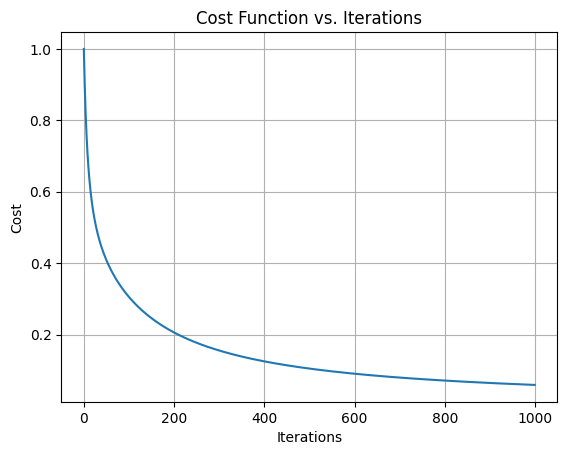

In [ ]:
# Initialize the weights and biases
d = X_train.shape[1]              # Number of features
c = y_train.shape[1]              # Number of classes
W = np.random.randn(d, c) * 0.01  # Small random weights
b = np.zeros(c)                   # Bias initialized to 0

# Set hyperparameters
alpha  = 0.1    # Learning rate
n_iter = 1000   # Number of iterations

# Train the model using gradient descent
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

# Plot the cost history to visualize the convergence
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

Evaluation Function

In [ ]:
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix,
    precision, recall, and F1-score.

    Parameters:
        y_true (numpy.ndarray): True labels
        y_pred (numpy.ndarray): Predicted labels

    Returns:
        tuple: Confusion matrix, precision, recall, F1 score
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute precision, recall, and F1-score
    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred, average='weighted')
    f1        = f1_score(y_true, y_pred, average='weighted')

    return cm, precision, recall, f1

Final Evaluation

In [ ]:
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# True labels in numeric form
y_test_labels = np.argmax(y_test, axis=1)

# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# Print the evaluation metrics
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Precision: 1.00
Recall:    1.00
F1-Score:  1.00
